## Rasterio Elevation Analysis

**Data:** USGS 3DEP 1/3 arc-second elevation raster (`elevation.tif`, Plumas/Butte County region) + CAL FIRE historical fire perimeters (`fire24_1.gdb`)

**What this notebook does:**
- Loads a USGS Digital Elevation Model (DEM) GeoTIFF with Rasterio and inspects its metadata: CRS, bounds, resolution, band count, and array shape
- Reprojects the Dixie Fire perimeter to match the raster CRS, then clips the elevation raster to the fire boundary using `rasterio.mask`
- Computes slope from the clipped elevation array using `np.gradient` and visualizes elevation vs. slope side by side — steeper terrain = higher fire spread risk
- Creates a composite raster + vector map overlaying the Dixie Fire perimeter on top of the clipped elevation raster using `rasterio.plot.show()`

In [48]:
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.merge import merge
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

### Load Dixie Fire Data

In [50]:
tile_paths = [
    '../data/raw/USGS_13_n40w121_20250514.tif',
    '../data/raw/USGS_13_n40w122_20250514.tif',
    '../data/raw/USGS_13_n41w121_20250514.tif',
    '../data/raw/USGS_13_n41w122_20250514.tif'
]

tiles = [rasterio.open(t) for t in tile_paths]
merged, merged_transform = merge(tiles)
print(merged.shape)

from rasterio.transform import array_bounds

# Save merged raster to disk
profile = tiles[0].profile
profile.update({
    'height': merged.shape[1],
    'width': merged.shape[2],
    'transform': merged_transform
})

with rasterio.open('../data/raw/merged_elevation.tif', 'w', **profile) as dst:
    dst.write(merged)


(1, 21612, 21612)


In [51]:
src = rasterio.open('../data/raw/merged_elevation.tif')
print(src.crs)
print(src.bounds)
print(src.res)
print(src.shape)


EPSG:4269
BoundingBox(left=-122.00055555599357, bottom=38.999444442930994, right=-119.99944444272971, top=41.000555556194854)
(9.259259269220167e-05, 9.259259269220167e-05)
(21612, 21612)


In [52]:
# Load Dixie Fire Data
gdf = gpd.read_file('../data/raw/fire24_1.gdb', layer='firep24_1')
dixie = gdf[(gdf['FIRE_NAME'] == 'DIXIE') & (gdf['YEAR_'] == 2021)]
print(dixie.crs)
dixie_4269 = dixie.to_crs(epsg=4269) # reproject to match the raster CRS
print(dixie_4269.crs)

EPSG:3310
EPSG:4269


In [53]:
# Clip the raster to the fire perimeter
clipped, clipped_transform = mask(src, dixie_4269.geometry, crop=True)
print(clipped.shape)

# Pull 2d elevation array from the clipped raster
elev = clipped[0]
print(elev.shape)

(1, 9983, 14642)
(9983, 14642)


### Calculate & Visualize Slope

nan nan


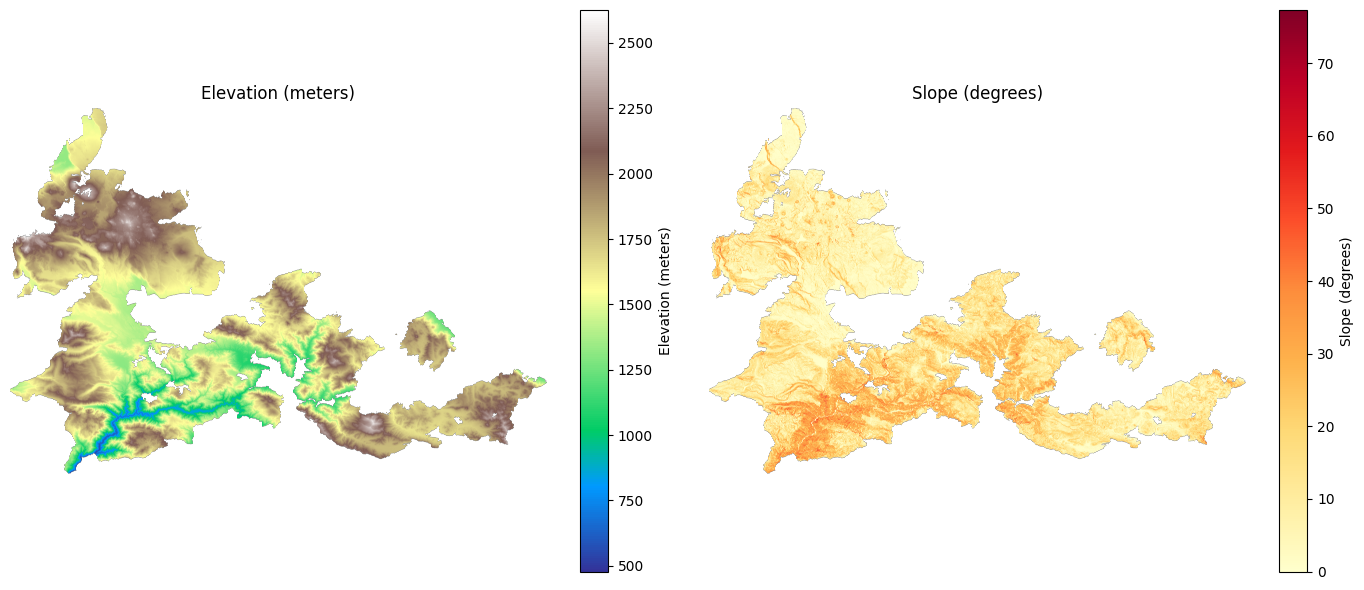

In [54]:
# replace nodata values with NaN
elev = elev.astype(float)
elev[elev == src.nodata] = np.nan

# Calculcate slope with numpy gradient
dy, dx = np.gradient(elev, 10, 10)
slope = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))
print(slope.min(), slope.max())

# Visualize the elevation and slope
fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 6))
im1 = ax1.imshow(elev, cmap='terrain')
plt.colorbar(im1, ax=ax1, label='Elevation (meters)')
ax1.set_title('Elevation (meters)')
ax1.axis('off')

im2 = ax2.imshow(slope, cmap='YlOrRd')
plt.colorbar(im2, ax=ax2, label='Slope (degrees)')
ax2.set_title('Slope (degrees)')
ax2.axis('off')

plt.tight_layout()
plt.show()

### Overlay fire perimer on elevation map for a composite raster/vector visualization